# Two-level Lorenz-96 — analysis-then-forecast setup

The two-level Lorenz-96 system (Wilks 2005, Arnold et al. 2013) is
the canonical **sub-grid** test problem for data assimilation.
Each slow variable $X_k$ couples to $J$ fast variables $Y_{j,k}$:

$$
\dot{X}_k = X_{k-1}(X_{k+1} - X_{k-2}) - X_k + F
          - \frac{hc}{b}\sum_{j=0}^{J-1} Y_{j,k},
$$

$$
\dot{Y}_{j,k} = -cb\, Y_{j+1,k}(Y_{j+2,k} - Y_{j-1,k})
              - c\, Y_{j,k} + \frac{hc}{b}\, X_k.
$$

With $h = 1, c = 10, b = 10, F = 20$ the system is fully chaotic
in both regimes. We use $K=8$ slow / $J=8$ fast → $D=72$ joint
state.

For the forecast-mode benchmark: 0.4-time-unit assim window
inside a 2-time-unit total run (~4 slow Lyapunov times). Slow
variables observed sparsely in space and time inside the assim
window; **fast variables receive no direct observations**.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from assimilation import Lorenz96TwoLevelForward, generate_l96_2l_problem

## 1. Decisions

| Parameter | Value | Rationale |
|---|---:|---|
| $K$ | 8 | Slow grid points. |
| $J$ | 8 | Fast variables per slow. |
| $D$ | 72 | Total flat state. |
| $F$ | 20.0 | Strongly chaotic regime. |
| $h, c, b$ | 1, 10, 10 | Canonical Wilks 2005 coupling. |
| $dt$ | 0.005 | Smaller than L96-1L's $dt$ because the fast scale is $c=10$ times faster. |
| $T_\text{assim}$ | 80 (0.4 time units) | Less than one slow Lyapunov time. |
| $T_\text{total}$ | 400 (2 time units) | ~4 slow Lyapunov times. |

## 2. Simulate a long trajectory

In [2]:
fwd_long = Lorenz96TwoLevelForward(K=8, J=8, F=20.0, h=1.0, c=10.0, b=10.0, dt=0.005)
key = jax.random.PRNGKey(0)
x0 = jnp.concatenate(
    [20.0 * jnp.ones(8), jnp.zeros(64)]
) + 0.05 * jax.random.normal(key, (72,))


def _scan(state, _):
    new = fwd_long.step(state, fwd_long.dt)
    return new, new


state, _ = jax.lax.scan(_scan, x0, None, length=2000)
_, traj_long = jax.lax.scan(_scan, state, None, length=500)
slow = traj_long[:, :8]
fast = traj_long[:, 8:]
print(f"slow range: [{float(slow.min()):.2f}, {float(slow.max()):.2f}]")
print(f"fast range: [{float(fast.min()):.2f}, {float(fast.max()):.2f}]")
print(f"slow std: {float(slow.std()):.2f}   fast std: {float(fast.std()):.2f}")
print(f"amplitude ratio slow/fast: "
      f"{float(slow.std() / fast.std()):.1f}  (theory: b = 10)")

slow range: [-13.48, 20.28]
fast range: [-1.07, 2.09]


slow std: 6.15   fast std: 0.35
amplitude ratio slow/fast: 17.5  (theory: b = 10)


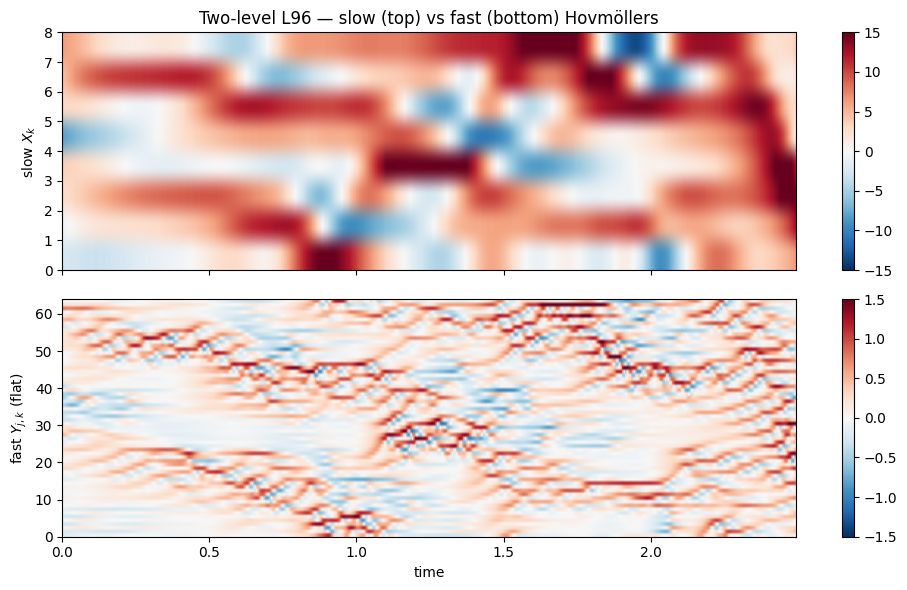

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = jnp.arange(500) * 0.005
im0 = axs[0].imshow(slow.T, aspect="auto", cmap="RdBu_r", origin="lower",
                    extent=(0, float(t[-1]), 0, 8), vmin=-15, vmax=15)
axs[0].set_ylabel("slow $X_k$")
axs[0].set_title("Two-level L96 — slow (top) vs fast (bottom) Hovmöllers")
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(fast.T, aspect="auto", cmap="RdBu_r", origin="lower",
                    extent=(0, float(t[-1]), 0, 64), vmin=-1.5, vmax=1.5)
axs[1].set_ylabel("fast $Y_{j,k}$ (flat)")
axs[1].set_xlabel("time")
fig.colorbar(im1, ax=axs[1])
fig.tight_layout()
plt.show()

## 3. Observation design

Inside the 0.4-time-unit assim window: observe every 2nd slow
grid point at every 0.05 time units (every 10 model steps). 4
spatial × 9 temporal = 36 scalar obs constraining $D=72$ initial
conditions — well-posed if the slow-fast coupling is informative.

In [4]:
prob = generate_l96_2l_problem(key=jax.random.PRNGKey(0))
print(f"K={prob.K}, J={prob.J}, D={prob.D}")
print(f"T_assim={prob.T_assim}, T_total={prob.T_total}")
print(f"obs density (slow only): {int(prob.mask.sum())} / "
      f"{prob.mask[:, : prob.K].size}")

K=8, J=8, D=72
T_assim=80, T_total=200
obs density (slow only): 36 / 648


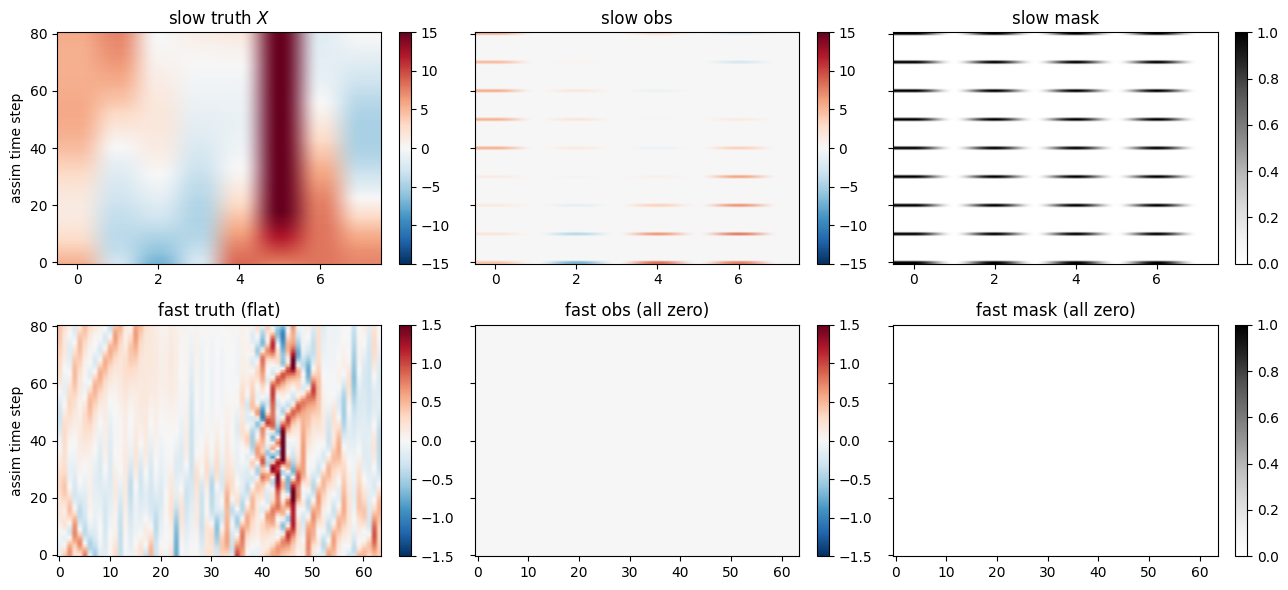

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6), sharey="row")
panels = [
    (prob.truth[: prob.T_assim_plus_1, : prob.K], "slow truth $X$", "RdBu_r",
     -15, 15),
    (prob.obs[:, : prob.K], "slow obs", "RdBu_r", -15, 15),
    (prob.mask[:, : prob.K], "slow mask", "Greys", 0, 1),
    (prob.truth[: prob.T_assim_plus_1, prob.K:], "fast truth (flat)",
     "RdBu_r", -1.5, 1.5),
    (prob.obs[:, prob.K:], "fast obs (all zero)", "RdBu_r", -1.5, 1.5),
    (prob.mask[:, prob.K:], "fast mask (all zero)", "Greys", 0, 1),
]
for ax, (field, title, cmap, vmin, vmax) in zip(axs.ravel(), panels, strict=False):
    im = ax.imshow(field, aspect="auto", cmap=cmap, origin="lower",
                   vmin=vmin, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
axs[0, 0].set_ylabel("assim time step")
axs[1, 0].set_ylabel("assim time step")
fig.tight_layout()
plt.show()

## 4. Forward roundtrip sanity check

In [6]:
fwd = Lorenz96TwoLevelForward(K=prob.K, J=prob.J, F=prob.F, h=prob.h,
                              c=prob.c, b=prob.b, dt=prob.dt)


def step(s, _):
    new = fwd.step(s, fwd.dt)
    return new, new


_, traj_rt = jax.lax.scan(step, prob.truth[0], None, length=prob.T_total)
truth_rt = jnp.concatenate([prob.truth[0][None, :], traj_rt], axis=0)
print(f"roundtrip max abs error: "
      f"{float(jnp.max(jnp.abs(truth_rt - prob.truth))):.2e}")

roundtrip max abs error: 0.00e+00


## 5. Next

Continue to
[`12_lorenz96_2l_benchmark`](12_lorenz96_2l_benchmark.ipynb) to see
how each method handles the slow-only observation regime —
crucially, whether the dynamics-aware methods can propagate slow
information into the unobserved fast block without degrading it.